In [2]:
# Cell 1: Core Imports and Seed Setup
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Set random seeds for reproducible results
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working with device: {device}")

Working with device: cpu


In [3]:
# Cell 2: Dataset Extraction & Saving CSV Data Sheet
cancer = load_breast_cancer()

# Construct DataFrame
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target  # 0 = Malignant, 1 = Benign

# Save to local directory as project dataset
csv_file = "breast_cancer_wisconsin.csv"
df.to_csv(csv_file, index=False)
print(f"Data sheet successfully saved locally as: {csv_file}")
print(f"Dataset Shape: {df.shape}")
df.head()

Data sheet successfully saved locally as: breast_cancer_wisconsin.csv
Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


--- Class Distribution ---
target
Benign (1)       357
Malignant (0)    212
Name: count, dtype: int64

Missing Values Count: 0


C:\Users\MYITEM.LK\AppData\Local\Temp\ipykernel_6944\185111475.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


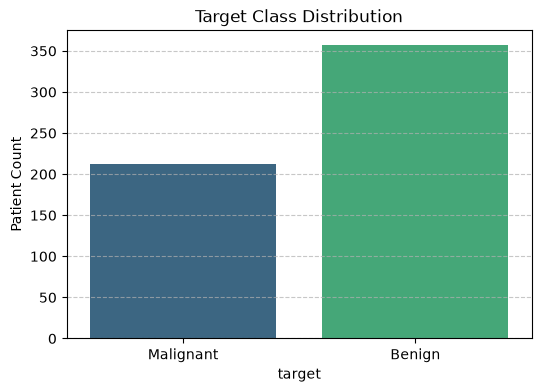

In [4]:
# Cell 3: Data Inspection & Visual Distribution
print("--- Class Distribution ---")
print(df['target'].value_counts().rename({0: 'Malignant (0)', 1: 'Benign (1)'}))

# Check for missing values
print("\nMissing Values Count:", df.isnull().sum().sum())

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.xticks(ticks=[0, 1], labels=['Malignant', 'Benign'])
plt.title('Target Class Distribution')
plt.ylabel('Patient Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [5]:
# Cell 4: Data Splitting and Feature Normalization
X = df.drop(columns=['target']).values
y = df['target'].values

# Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Standard Scaling (Zero mean, Unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch Tensors & DataLoaders
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 455, Test samples: 114


In [6]:
# Cell 5: Neural Network Architecture Definition
class BreastCancerANN(nn.Module):
    def __init__(self, input_dim):
        super(BreastCancerANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1)  # Output single raw logit
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
model = BreastCancerANN(input_dim=input_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(model)

BreastCancerANN(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [7]:
# Cell 6: Training and Validation Loop
EPOCHS = 60
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    # --- Training Phase ---
    model.train()
    running_train_loss, train_correct, train_total = 0.0, 0, 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * X_batch.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)
        
    epoch_train_loss = running_train_loss / train_total
    epoch_train_acc = train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # --- Validation Phase ---
    model.eval()
    running_val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            
            running_val_loss += loss.item() * X_batch.size(0)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
            
    epoch_val_loss = running_val_loss / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    # Save best model weight checkpoint
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_cancer_ann_model.pth')
        
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{EPOCHS} | "
              f"Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.4f}")

Epoch 01/60 | Train Loss: 0.5654 - Acc: 0.7516 | Val Loss: 0.5264 - Acc: 0.8684
Epoch 10/60 | Train Loss: 0.1507 - Acc: 0.9538 | Val Loss: 0.1767 - Acc: 0.9649
Epoch 20/60 | Train Loss: 0.1055 - Acc: 0.9692 | Val Loss: 0.1004 - Acc: 0.9561
Epoch 30/60 | Train Loss: 0.0792 - Acc: 0.9736 | Val Loss: 0.0955 - Acc: 0.9649
Epoch 40/60 | Train Loss: 0.0770 - Acc: 0.9670 | Val Loss: 0.0736 - Acc: 0.9825
Epoch 50/60 | Train Loss: 0.1060 - Acc: 0.9604 | Val Loss: 0.0800 - Acc: 0.9649
Epoch 60/60 | Train Loss: 0.0489 - Acc: 0.9758 | Val Loss: 0.0716 - Acc: 0.9737


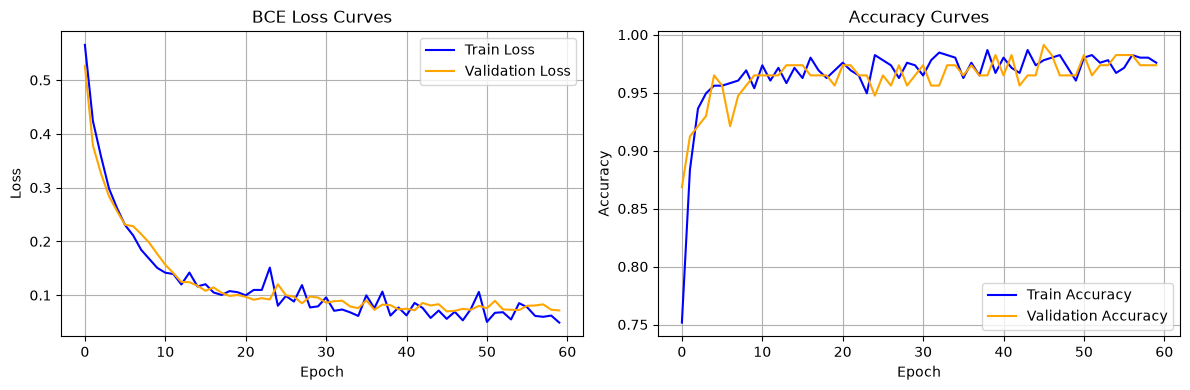


--- Final Test Classification Report ---
               precision    recall  f1-score   support

Malignant (0)       1.00      0.98      0.99        42
   Benign (1)       0.99      1.00      0.99        72

     accuracy                           0.99       114
    macro avg       0.99      0.99      0.99       114
 weighted avg       0.99      0.99      0.99       114



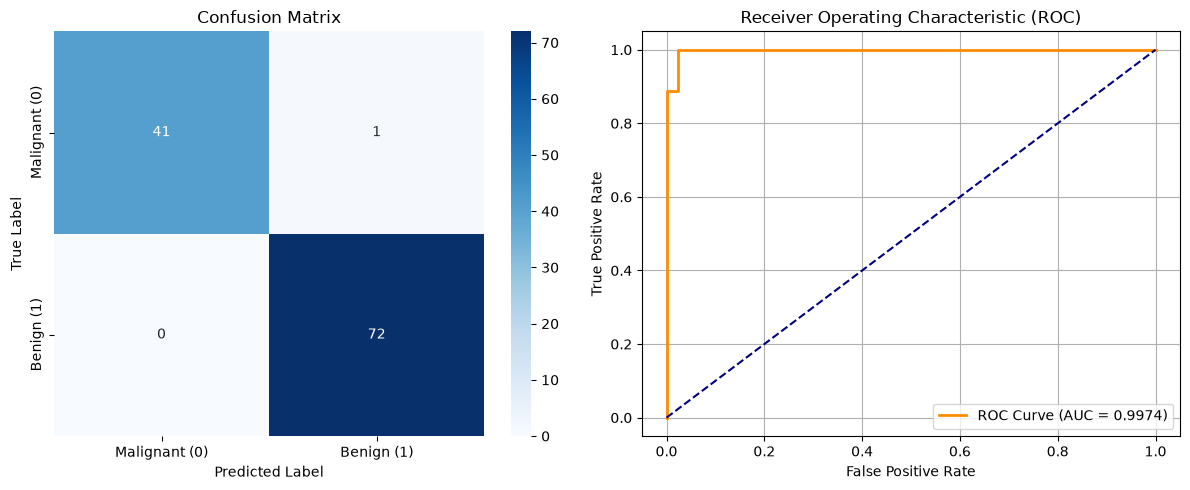

In [8]:
# Cell 7: Loss/Accuracy Plots, Confusion Matrix, and ROC Curve
# Load optimal checkpoint weights
model.load_state_dict(torch.load('best_cancer_ann_model.pth'))
model.eval()

# 1. Plot Training History Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(val_losses, label='Validation Loss', color='orange')
ax1.set_title('BCE Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label='Train Accuracy', color='blue')
ax2.plot(val_accuracies, label='Validation Accuracy', color='orange')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 2. Extract Test Predictions
y_probs_list, y_true_list = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits)
        y_probs_list.extend(probs.cpu().numpy())
        y_true_list.extend(y_batch.numpy())

y_probs = np.array(y_probs_list).ravel()
y_true = np.array(y_true_list).ravel()
y_pred = (y_probs >= 0.5).astype(int)

# 3. Print Classification Report
target_names = ['Malignant (0)', 'Benign (1)']
print("\n--- Final Test Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Plot Confusion Matrix & ROC Curve
fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax_cm)
ax_cm.set_title('Confusion Matrix')
ax_cm.set_xlabel('Predicted Label')
ax_cm.set_ylabel('True Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)
ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax_roc.set_title('Receiver Operating Characteristic (ROC)')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
ax_roc.grid(True)

plt.tight_layout()
plt.show()